# Quantum pricing of a European call option using Quantum Amplitude Estimation

**Authors:** COULIBALY Famagan & REGERT Jonathan (2A-IF)

## Introduction

In this project, we study how a quantum circuit can be used to approximate the **compounded price** of a European call option.  
We first compute classical reference values using the Black-Scholes formula and a Monte Carlo simulation.  
Then, we discretize the distribution of the final stock price, encode this distribution into a quantum state, and build a circuit whose output amplitude is related to the expected payoff of the option.  
Finally, we apply a Quantum Amplitude Estimation routine and compare the obtained result with the classical benchmarks.

The notebook is organized as a short report: each section introduces the idea behind the code and comments on the main numerical results.


In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library.standard_gates import RYGate, XGate
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem, FasterAmplitudeEstimation
from itertools import product
from scipy.stats import norm, lognorm


# Standard pricing of a call option

The first part of this project consists in computing the price of a call option using the Black-Scholes closed formula, and then approximating it using a Monte Carlo method.

## Black-Scholes price of the call option

Definition of the function implementing the closed formula for the price of a call option

**The Black-Scholes formula** directly gives the price of a **call option** at time t = 0, "today".

In [2]:
def black_scholes_call(S, K, T, r, sigma):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

### Characteristics to price the call option

In [3]:
# Financial characteristics that are also required to compute the probability distribution
sigma = 0.2 # volatility (annualized)
T = 1 # maturity (in years)
r = 0.05 # risk-free rate (annualized)
S0 = 2 # initial stock price
K = 2 # strike price

Evaluation of the price for the given set of parameters

In [4]:
call_price = black_scholes_call(S0, K, T, r, sigma)
print(f"Call option price: {call_price}")

Call option price: 0.20901167144371136


The Black-Scholes formula gives a price C0 of about **0.209**, that is, the amount the buyer pays today to acquire the call option.

## Compounded Black-Scholes price of the call option

In this project, we are actually interested in the compounded value of the call price. Data is stored in dictionaries.

Dictionary for the pricing characteristics

In this section, we transform the call price obtained previously in order to express it at the maturity date $T$.

In [5]:
price_dict = {'S0': S0, 'r': r, 'sigma': sigma, 'T': T}

In [6]:
def compound_black_scholes_call(price_dict, K):
    """
    Calculate the Black-Scholes price for a European call option.
    
    :param S: Current stock price
    :param K: Strike price
    :param T: Maturity (in years)
    :param r: Risk-free interest rate (annual)
    :param sigma: Volatility of the stock (annual)
    :return: Call option price
    """
    S0 = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']
    call_price = black_scholes_call(S0, K, T, r, sigma)
    compound = np.exp(r * T) * call_price
    return compound 

In [7]:
compound_call_price = compound_black_scholes_call(price_dict, K)
print(f"Compounded call option price: {compound_call_price}")

Compounded call option price: 0.21972792899401578


The call price at maturity $T$ is about **0.2197**. This is the value that the quantum algorithm will try to estimate.

## Monte Carlo evaluation of the compounded price of the call option

Complete the code below to evaluate the compounded price of the call option. A sample of $\mathcal{N}(0,1)$ can be generated using the command `random.standard_normal` from **numpy**

We check the Black-Scholes price using a Monte Carlo simulation. The result obtained is close to the reference value, which validates our implementation.

In [8]:
def monte_carlo_black_scholes(price_dict, K, num_simulations):
    """
    Monte Carlo simulation for Black-Scholes option pricing.
    
    :param price_dict: Dictionary containing the pricing characteristics
    :param K: Strike price
    :param num_simulations: Number of Monte Carlo simulations
    :return: Option price
    """
    S0 = price_dict['S0']
    T = price_dict['T']
    r = price_dict['r']
    sigma = price_dict['sigma']
    acc = 0.0
    for i in range( num_simulations):
        G = np.random.standard_normal() # normal distribution
        S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*G)
        acc += np.maximum(S_T - K, 0.0)
    compound_option_price = acc/num_simulations
    return compound_option_price 

In [9]:
monte_carlo_black_scholes(price_dict, K, 50000)

np.float64(0.21884544039105613)

The result of the Monte Carlo simulation is very close to the Black-Scholes price (about 0.2197), which confirms that our reference value is correct.

The goal of the project is to implement a quantum algorithm that can be used to approximate the compounded price.

## From classical pricing to the quantum circuit

The rest of the notebook is devoted to the construction of the quantum pricing circuit.  
Main components are:
1. an encoding of the payoff through affine functions and controlled rotations,
2. a comparator that detects whether the discretized final price is above the strike,
3. an encoding of the probability distribution of the final stock price,
4. a final integration step combined with amplitude estimation.


# Storing a linear function in a quantum state

## Presentation
The goal of this part is to construct a circuit that permits to encode an affine function $f: x\mapsto a + bx$ on $n$ qubits, under the constraint that $a$ and $b$ are such that $f(x) \in [0,1]$ for all $x\in \{0, \ldots, 2^n-1\}$.

The encoding is based on the approximation $\sin^2\left(y + \frac{\pi}{4}\right) = y + \frac{1}{2} + O\left(y^3\right)$, where $y$ is replaced by $d\cdot\left(f(x) + \frac{1}{2}\right)$.

## Encoding the affine function

Create a method `encode_affine_function`$(n,a,b)$ that encodes the function $f$ defined above using rotation gates. Recall that the circuit consists of $n+1$ qubits.

In [10]:
def encode_affine_function(n, a, b):
    circ= QuantumCircuit(n+1)
    
    # constant rotation 
    circ.ry(2*a, 0)

    # controlled rotations for each x 
    for i in range(1,n+1):
        angle= b * (2 ** i)
        circ.cry(angle, i, 0)
    
    return  circ 

## Testing the circuit

The goal of this part is to make sure that the designed circuit behaves as expected for all inputs.

### Helper functions for amplitude estimation on the constructed circuit

The functions below are provided so that they can be used to make sure the constructed circuit behaves as expected.

In [11]:
def to_bin(n, i):
    """
    Convert integer i to binary string of length n and append '1' to the end.
    """
    bini = format(i, f'0{n}b')
    res = bini + '1'
    return res

In [12]:
def get_state_probabilities(qc):
  """
  Retrieve the probabilities of each basis state from the statevector of the input quantum circuit.
  """
  n = qc.num_qubits
  statevector = Statevector(qc)
  probabilities = {}
  for i in range(2**n):
    state = bin(i)[2:].zfill(n)
    probabilities[state] = abs(statevector[i])**2  
  return probabilities

In [13]:
def get_output_prob(qc, i):
    '''For a circuit with n qubits, returns the probability of reading a '1' on qubit 0 when qubits 1 to n are in the state i'''
    n = qc.num_qubits - 1
    state_probs = get_state_probabilities(qc)
    output_prob = state_probs[to_bin(n,i)]
    return output_prob

Define a method `convert_affine`$(a,b,d)$ that outputs values `a_out` and `b_out` for the transformed affine function.

In [14]:
def convert_affine(a, b, d):
    a_out = d * (a - 0.5) + np.pi/4
    b_out = b*d
    return a_out, b_out

Create an `initializer` function that takes as an input a quantum circuit consisting of $n$ qubits and an integer $0\leq i \leq 2^{n-1} -1$, and creates a new quantum circuit in which the initial state is $|i\rangle$ on the input qubits (and $|0\rangle$ on the output qubit).

In [15]:
def initializer(circ, i):
    n = circ.num_qubits - 1
    qc = QuantumCircuit(n+1) # we build a circuit with n input qubits and one output qubit 
    res = to_bin(n,i)[:-1] # convert integer i to binary and remove the 1 that is added in bin
    state1 = Statevector.from_label(res) # transform into a state 
    state2 = Statevector.from_label("0") # the output qubit
    state = state1.tensor(state2)
    qc.initialize(state)
    return qc.compose(circ)
    

Create a method `compare_values`$(n,a,b,d,i)$ that compares the expected value 
$$d\cdot\left(f(i)-\frac{1}{2}\right) + \frac{1}{2} = d\cdot\left(a+i\cdot b - \frac{1}{2}\right) + \frac{1}{2}$$
with the probability of measuring value $1$ on qubit $0$ in the constructed circuit. The method should print the expected value, the probability of measuring the value $1$ and the relative error between both.

This method is in charge of:
- Invoking `convert_affine` to get the appropriate parameters for the encoded affine function
- Creating the initial circuit (`encode_affine_function`)
- Invoking the `initializer` to set the desired initial state
- Retrieving the probability of reading a $1$ on qubit $0$

In [16]:
def compare_values( n, a,b, d, i):
    # expected value 
    value = d * ( a + i*b - 0.5) + 0.5
    
    # affine conversion
    a_conv, b_conv = convert_affine(a, b, d)

    # circuit creation and initialization 
    circ = encode_affine_function( n, a_conv, b_conv)
    circ_init = initializer(circ, i)

    # probability of reading 1 on the qubit 
    prob = get_output_prob(circ_init, i)

    # relative error
    rel_error = abs(value - prob) / value
    print(f"i={i} | expected={value:.6f} | prob={prob:.6f} | error={rel_error:.6%}")
    

In [17]:
def compare_all_values(n, a, b, d):
    for i in range(2**n):
        compare_values(n, a, b, d, i)

### Definition of constants for testing purposes

In [18]:
# Number of qubits in the circuit
n_test = 3

# Arbitrary value for b
b_test = 1.0/(2**n_test)

# Arbitrary value for a, with the constraint that 0 <= f(x) <= 1 for all x
a_test = 1.0/(2**(n_test+1))

# Arbitrary value for d
d_test = 0.1

In [19]:
pure_affine = encode_affine_function(n_test, a_test, b_test)

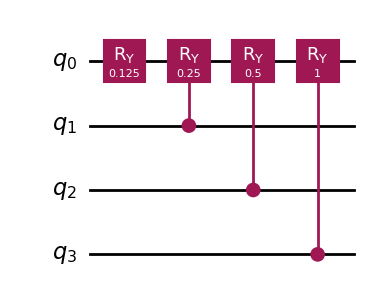

In [20]:
pure_affine.draw(output='mpl')

Invoking `compare_all_values` with the defined constants:

In [21]:
compare_all_values(n_test, a_test, b_test, d_test)

i=0 | expected=0.456250 | prob=0.456306 | error=0.012231%
i=1 | expected=0.468750 | prob=0.468770 | error=0.004339%
i=2 | expected=0.481250 | prob=0.481254 | error=0.000913%
i=3 | expected=0.493750 | prob=0.493750 | error=0.000033%
i=4 | expected=0.506250 | prob=0.506250 | error=0.000032%
i=5 | expected=0.518750 | prob=0.518746 | error=0.000847%
i=6 | expected=0.531250 | prob=0.531230 | error=0.003829%
i=7 | expected=0.543750 | prob=0.543694 | error=0.010263%


The results show that the circuit correctly encodes the affine function for all values of $i$, with a relative error below **0.013%**. This very small error is due to the approximation $\sin^2(y + \pi/4) \approx y + 1/2$, which becomes more accurate when the values of $y$ remain close to zero.

# Quantum circuit for integer comparison

The goal of this part is to construct a circuit of size $n$, parameterized by an integer $0\leq L \leq 2^n-1$, that permits to detect whether a given state $|i\rangle$ is such that $i < L$ or $i\geq L$.

## Creation of the 'or' gate

Define a method `or_gate`() that constructs a quantum circuit representing an *or* gate using the method described in the exercise sheet. Formally, the constructed gate $\mathrm{Or}$ should be such that
$$\mathrm{Or}\cdot|xyz\rangle = |xy\rangle \otimes |z\oplus (x \vee y)\rangle.$$

In [22]:
def or_gate(qc) : 
    # Toffoli: z becomes z⊕(x∧y)
    qc.ccx(2,1,0) 
    
    # CNOT on x (control) and z as the target
    qc.cx(2,0) # Z becomes z⊕(x∧y)⊕x
    
    # CNOT gate on y (control) and z as the target
    qc.cx(1,0) # Z becomes z⊕(x∧y)⊕x⊕y = x ∨ y
    

qc = QuantumCircuit(3)
or_gate(qc)
qc.draw(output='mpl')

We can verify that the *or* gate has the appropriate behavior by computing the probabilities of measuring a $1$ on qubit $0$ for different initial states.


**Useful methods**: 
- The `initialize` and `get_output_prob` methods defined above.

In [23]:
def test_or_gate():
    qc=QuantumCircuit(3)
    for i in range(4):
        qc_init= initializer(qc,i)
        or_gate(qc_init)
        prob = get_output_prob(qc_init,i)
        print(f"i={i} | probability = {prob:.6f}")
        

In [24]:
test_or_gate()

i=0 | probability = 0.000000
i=1 | probability = 1.000000
i=2 | probability = 1.000000
i=3 | probability = 1.000000


The OR gate works correctly: the probability of reading $|1\rangle$ on the output qubit is **0** for input $(0,0)$ and **1** for all the other inputs, which matches the truth table of the OR gate.

## Construction of the comparator circuit

Define a `make_comparator`$(n,L)$ function that creates a circuit of size $2n$ such that, when state $|i\rangle \otimes |0^n\rangle$ is fed as an input, we have $|q_0\rangle = |0\rangle$ exactly when $i < L$. 

In [25]:
def make_comparator(n, L):
    qc = QuantumCircuit(2 * n)
    
    # Bits of K in little-endian order: k_0 is the least significant bit
    k = [(L >> j) & 1 for j in range(n)]
    
    input_q = list(range(n, 2*n))  # x_0..x_{n-1}
    s_q     = list(range(n))       # s_0..s_{n-1}
    
    # Base case j=0
    if k[0] == 0:
        qc.x(s_q[0])               # s_0 = 1 because x_0 >= 0 always
    else:
        qc.cx(input_q[0], s_q[0])  # s_0 = x_0
    
    # Recursive case j=1..n-1
    for j in range(1, n):
        if k[j] == 0:
            # s_j = x_j OR s_{j-1}
            qc.cx(input_q[j], s_q[j])
            qc.cx(s_q[j-1], s_q[j])
            qc.ccx(input_q[j], s_q[j-1], s_q[j])
        else:
            # s_j = x_j AND s_{j-1}
            qc.ccx(input_q[j], s_q[j-1], s_q[j])
    
    return qc



Define a `check_comparison`$(n,L)$ method that invokes the `make_comparator` method, iterates over $0\leq i\leq 2^n-1$ to initialize the circuit with state $|i\rangle \otimes |0^n\rangle$ and verifies that the measurement of qubit $0$ returns the appropriate value for each value of $i$.

You can use the `get_one_prob` method below, which permits to compute the probability of reading value '1' on qubit $0$ upon a measurement. 

In [26]:
def get_one_prob(qc):
    """
    For a circuit with n qubits, returns the probability of reading a '1' on qubit 0
    """
    state_probs = get_state_probabilities(qc)
    n = qc.num_qubits - 1
    result = 0
    for i in range(2**n):
        bin_i = to_bin(n, i)
        result += state_probs[bin_i]
    return result

In [27]:
def check_comparison(n, L):
    qc_base = make_comparator(n, L)
    for i in range(2**n):
        qc = QuantumCircuit(2 * n)
        for k in range(n):
            if (i >> k) & 1:
                qc.x(n + k)
        qc = qc.compose(qc_base)
        
        # Read the result on qubit n-1
        state_probs = get_state_probabilities(qc)
        prob = sum(v for k, v in state_probs.items() if k[n] == '1')
        
        expected = 0.0 if i < L else 1.0
        print(f"i={i} | expected={expected:.0f} | obtained={prob:.4f}")

In [28]:
check_comparison(4,8)

i=0 | expected=0 | obtained=0.0000
i=1 | expected=0 | obtained=0.0000
i=2 | expected=0 | obtained=0.0000
i=3 | expected=0 | obtained=0.0000
i=4 | expected=0 | obtained=0.0000
i=5 | expected=0 | obtained=0.0000
i=6 | expected=0 | obtained=0.0000
i=7 | expected=0 | obtained=0.0000
i=8 | expected=1 | obtained=1.0000
i=9 | expected=1 | obtained=1.0000
i=10 | expected=1 | obtained=1.0000
i=11 | expected=1 | obtained=1.0000
i=12 | expected=1 | obtained=1.0000
i=13 | expected=1 | obtained=1.0000
i=14 | expected=1 | obtained=1.0000
i=15 | expected=1 | obtained=1.0000


The comparator circuit works perfectly: for $L=8$ and $n=4$, the result qubit is **0** for all values $i < 8$ and **1** for all values $i \geq 8$, without any error.

We will now store the probability distribution of the final price in a quantum state, which will allow us to encode the expected payoff in the amplitude of the circuit.

## Discretization of the final price distribution

In order to use a finite-size quantum register, we replace the continuous distribution of the final price of the underlying asset with a discrete grid. This gives us a family of prices $(s_i)$ and associated probabilities $(p_i)$, which are then encoded in a quantum state of the form:

$$|\psi\rangle = \sum_i \sqrt{p_i}\,|i\rangle.$$

This is the first main quantum ingredient of the pricing circuit.

# Storing a probability distribution in a quantum state

The goal of this part is to design a circuit that permits to store a probability distribution in a quantum state.

## Case where $n=2$

We begin with the simple case where $n=2$. Complete the cell below to construct the circuit permitting to store the probability distribution in a quantum state (with a single qubit). 

With a correctly implemented circuit, the probability of getting the outcome $0$ is close to $p$, likewise for $1$ and $1-p$.

## Circuit for an arbitrary value of $n$.

### Generation of the final prices grid

Use the `linspace` method from **numpy** to define a method `make_final_price_grid`$(n, \mathrm{price\_dict}, m)$ that generates a regular grid with size $2^n$ of final prices ranging between $\max\left(0, \overline{S} - m\cdot \sigma\right)$ and $\overline{S} + m\cdot \sigma$.

In [29]:
def make_final_price_grid(n,price_dict,m):
    # price_dict contains the parameters of the underlying asset
    S0= price_dict['S0']
    T = price_dict['T']
    sigma = price_dict["sigma"]
    price_dict["sigma"]
    
    r = price_dict['r']
    S_bar = S0*np.exp(r*T)
    S_m= max(0, S_bar - m * sigma) # lower bound
    S_M= S_bar + m * sigma # upper bound
    
    return np.linspace(S_m, S_M, 2**n)

Define a method `align`$(n, K, \mathrm{price\_dict}, m)$ that returns the value $L$ such that $s_L$ is the projection of $K$ on the final price grid.

In [30]:
def align(n,K,price_dict,m):
    grid = make_final_price_grid(n,price_dict,m)
    L = np.argmin(np.abs(grid - K)) # projection of K onto the final-price grid 
    S_L= grid[L]
    return int(L), S_L

Test the discretization error by comparing the outputs of `compound_black_scholes_call` on an arbitrary strike and on its projection on the final price grid.

In [31]:
init_cpb = compound_black_scholes_call(price_dict, price_dict['S0'])
disc_cpb = compound_black_scholes_call(price_dict, align(5,price_dict['S0'], price_dict, 3)[1])

In [32]:
print(f'init: {init_cpb}, disc: {disc_cpb}, error: {(init_cpb-disc_cpb)/init_cpb:.2%}')

init: 0.21972792899401578, disc: 0.2165164556850805, error: 1.46%


The discretization error is **1.46%**, which means that the grid point $s_L$ closest to the strike $K$ introduces a slight difference compared with the exact price.

### Generation of the probability values

Define a method `make_probability_distribution` that returns a tuple with the last prices grid and the corresponding value of each $p_i$ for $0 \leq i < 2^n$. The arguments of this method are:
- $n$: the number of qubits under consideration
- $\mathrm{price\_dict}$: the dictionary with the mathematical characteristics of the underlying
- $m$: the number of standard deviations to consider for the minimum and maximum bounds of the grid

***Useful methods:*** 
$S_T$ is of the form $S_0e^{(r-\tfrac{\sigma^2}{2})T}\cdot Z$, where $Z \sim \mathrm{lognorm}(\sigma\sqrt{T})$. The lognormal distribution is available thanks to the `lognorm` method from `scipy.stats`. The `scale` parameter is to be set to $1$.

The probability values can be computed using the `cdf` method available on the lognormal distribution.

In [33]:
def make_probability_distribution(n , price_dict, m):
    S0= price_dict['S0']
    T = price_dict['T']
    sigma = price_dict['sigma']
    r = price_dict['r']
    
    grid = make_final_price_grid(n,price_dict,m)
    # Z~logN(s, scale = 1) with s = sigma*sqrt(T)
    s = sigma*np.sqrt(T)
    factor = S0 * np.exp((r - sigma**2 / 2) * T)
    dist = lognorm(s=s, scale=1)

    # Probability p_i
    probs=[]
    step = grid[1] - grid[0]
    for i in range(2**n):
        s_i = grid[i]
        s_i_next = grid[i] + step
        p_i = dist.cdf(s_i_next / factor) - dist.cdf(s_i / factor)
        probs.append(p_i)

    probs = np.array(probs)
    probs = probs / probs.sum()

    return grid, probs
        

## Validation of the probability distribution, comparison of the Black-Scholes approximation

In [34]:
# Arbitrary value for n, will afterward be the size of the quantum circuit
n_prob = 10
n_stddev_prob = 4

Verify that the generated distribution sums to $1$.

In [35]:
final_prices, prob_distribs = make_probability_distribution(n_prob, price_dict, n_stddev_prob)
np.sum(prob_distribs)

np.float64(1.0)

The sum of the probabilities is indeed $1$, which validates the normalization of the discrete distribution. Each $p_i$ is computed as the probability that $S_T$ falls in the interval $[s_i, s_{i+1})$, obtained by taking the difference between CDF values of the log-normal distribution.

Plot the generated distribution against the final price grid.

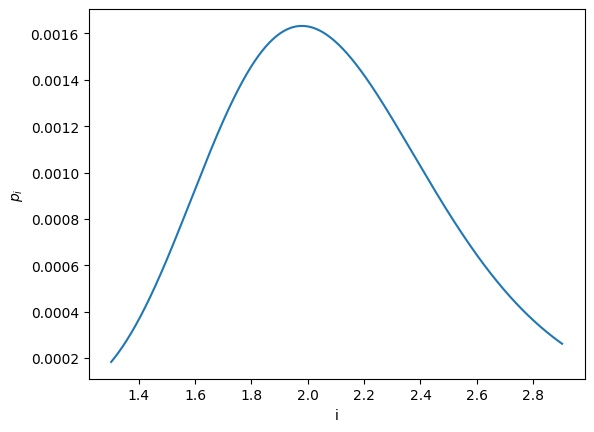

In [36]:
plt.plot(final_prices, prob_distribs)
plt.xlabel('i')
plt.ylabel('$p_i$')
plt.show()

The graph shows the probability distribution of the final prices of the underlying asset. We can see that the most likely prices are concentrated around **2.0**, which is consistent with the initial price $S_0 = 2$ and the risk-free rate applied over the lifetime of the option. The curve is slightly spread out to the right, which is a known property of the log-normal distribution.

Compare the compounded Black-Scholes price of an option with the approximation of the expectation 
$$\mathbb{E}\left[(S_T - s_L)_+\right] \approx \sum_{i=0}^{2^n-1}p_i\cdot(s_i - s_L)_+.$$

In [37]:
def expectation_cmp(n, L, price_dict, n_stddev):
    last_prices, prob_distribs = make_probability_distribution(n, price_dict, n_stddev)
    S_L  = last_prices[L]
    terme_max = np.maximum(0, last_prices - S_L)
    sum = np.sum(terme_max * prob_distribs) 
    compound_bs = compound_black_scholes_call(price_dict, S_L)
    
    return {'bs': compound_bs, 'sum': sum, 'strike': S_L}

In [38]:
def get_all_expect_comp(n, price_dict, num_stddev, num_points):
    res = []
    for L in range(0, 2**n,int(2**n/num_points)):
        ex_cmp = expectation_cmp(n, L, price_dict, num_stddev)
        print(f'L: {L} (strike {ex_cmp["strike"]})')
        res.append(ex_cmp)
    return res

In [39]:
res = get_all_expect_comp(n_prob, price_dict,n_stddev_prob, 20)

L: 0 (strike 1.3025421927520482)
L: 51 (strike 1.3823075886464764)
L: 102 (strike 1.4620729845409044)
L: 153 (strike 1.5418383804353326)
L: 204 (strike 1.6216037763297608)
L: 255 (strike 1.701369172224189)
L: 306 (strike 1.7811345681186173)
L: 357 (strike 1.8608999640130452)
L: 408 (strike 1.9406653599074735)
L: 459 (strike 2.0204307558019017)
L: 510 (strike 2.1001961516963297)
L: 561 (strike 2.179961547590758)
L: 612 (strike 2.259726943485186)
L: 663 (strike 2.339492339379614)
L: 714 (strike 2.4192577352740425)
L: 765 (strike 2.499023131168471)
L: 816 (strike 2.5787885270628985)
L: 867 (strike 2.658553922957327)
L: 918 (strike 2.7383193188517554)
L: 969 (strike 2.8180847147461834)
L: 1020 (strike 2.8978501106406114)


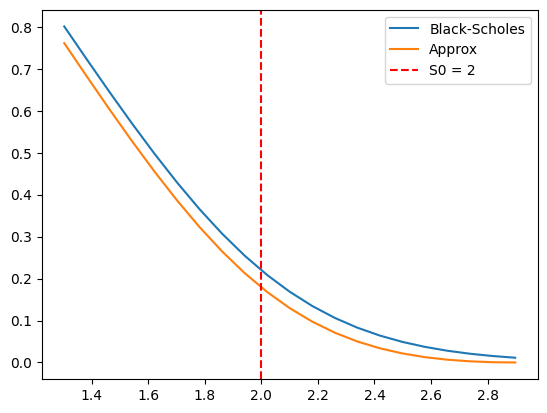

In [40]:
resbs = [x['bs'] for x in res]
ressum = [x['sum'] for x in res]
strikes = [x['strike'] for x in res]
xcoord = price_dict['S0']
plt.plot(strikes, resbs, label='Black-Scholes')
plt.plot(strikes, ressum, label='Approx')
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'S0 = {xcoord}')
plt.legend()
plt.show()

Both curves are decreasing and follow the same trend: the higher the strike, the lower the call price. The approximation (in orange) is slightly below the Black-Scholes price (in blue) over the whole range of strikes, with a larger gap for low strikes that gradually decreases for higher strikes.

In [41]:
abs_errors = [(x['sum'] - x['bs']  ) for x in res]

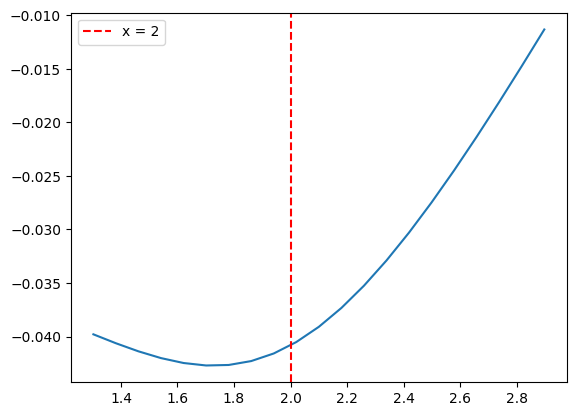

In [42]:
plt.plot(strikes, abs_errors)
xcoord = price_dict['S0']
plt.axvline(x=xcoord, color='r', linestyle='--', label=f'x = {xcoord}')
plt.legend()
plt.show()

## Recursive distribution computations

We compute  the values $q_w$ and $\theta_w$. The values of $q_w$ (resp. $\theta_w$) where $w$ is of length $m$ are stored in a dictionnary where each key is a string of length $m$. The dictionnaries with the values of $q$ (resp. $\theta$) for $1 \leq m \leq n$ are stored in a dictionnary `DictQ` (resp. `DictTheta`).

Define a function `generate_binary_strings` that takes a parameter $n$ and outputs a list of all binary strings of length $n$.

Useful method: `product` from the `itertools` package

In [43]:
def generate_binary_strings(n):
    listes = list( product([0,1], repeat = n))
    return [''.join(map(str, bits)) for bits in listes]


Define a method `make_dict_at_n` that creates the dictionary containing the values $q_w$ where $w$ is of length $n$. This method has two parameters:
- the value of $n$
- the initial probability distribution

In [44]:
def make_dict_at_n(n, dist_prob_init ):
    binary = generate_binary_strings(n)
    res ={}
    for i, w  in enumerate(binary ):
        res[w]  = dist_prob_init[i]
        
    return res
    

Define a method `make_all_dictQ` that iterates from $n-1$ to $1$ to generate all the required probability distributions. Note that the set of keys in the generated dictionary is $\{1, \ldots, n\}$. This method has two parameters:
- the value of $n$
- the dictionary containing the probability distribution at level $n$ (generated by `make_dict_at_n`)

In [45]:
def make_all_dictQ(n, dict_at_n):
    DictQ = {n: dict_at_n}
    for m in range(n-1, 0, -1):
        DictQ[m] = {}
        for w in generate_binary_strings(m):
            DictQ[m][w] = DictQ[m+1][w + '0'] + DictQ[m+1][w + '1']
    
    return DictQ


Define a method `make_all_dictTheta` that iterates from $0$ to $n-1$ to generate all the required angles. Note that the set of keys in the generated dictionary is $\{0, \ldots, n-1\}$. This method has a single parameter: the dictionary generated by `make_all_dictQ`.

For the sake of convenience, the element at key $0$ in the generated dictionary will be the angle $\theta^{[0]}_\varepsilon$ instead of a dictionary containing this angle (with the empty string as a key).

In [46]:
def make_all_dictTheta(all_dicts_q):
    n = max(all_dicts_q.keys())
    all_thetas = {}
    
    # m=0: single theta_epsilon angle
    all_thetas[0] = 2 * np.arccos(np.sqrt(all_dicts_q[1]['0']))
    
    # m=1 to n-1
    for m in range(1, n):
        all_thetas[m] = {}
        for w in generate_binary_strings(m):
            q_w    = all_dicts_q[m][w]
            q_w0   = all_dicts_q[m+1][w + '0']
            all_thetas[m][w] = 2 * np.arccos(np.sqrt(q_w0 / q_w))
    
    return all_thetas

Define a method `make_qc_for_dict` that creates the general quantum circuit for the storage of a quantum distribution. This method has a unique parameter: the dictionary of rotation angles (generated by `make_all_dictTheta`).

Some useful concepts and methods from Qiskit:
- `RYGate` for $y$-rotation gates that are potentially controlled
- `control`: the method to create the controlled version of a quantum gate. This method takes as parameters the number of control qubits, and possibly the state of the control qubits that will trigger the gate (`ctrl_state`).

In [47]:
def make_qc_for_dict(all_thetas):
    n = max(all_thetas.keys()) + 1
    qc = QuantumCircuit(n)
    
    # m=0: initial rotation on qubit n-1 (the highest one)
    qc.ry(all_thetas[0], n-1)
    
    # m=1 to n-1: controlled rotations, from top to bottom
    for m in range(1, n):
        controls = list(range(n-1, n-1-m, -1))  # qubits n-1 to n-m
        target   = n-1-m                          # target qubit
        for w in generate_binary_strings(m):
            theta = all_thetas[m][w]
            gate  = RYGate(theta).control(m, ctrl_state=w)
            qc.append(gate, controls + [target])
    
    return qc

## Example

In [48]:
n_circ = 3
circ_distrib = make_probability_distribution(n_circ, price_dict, 3)[1]

In [49]:
dict_pn = make_dict_at_n(n_circ, circ_distrib)

In [50]:
dict_all_q = make_all_dictQ(n_circ, dict_pn)

In [51]:
dict_all_theta = make_all_dictTheta(dict_all_q)

In [52]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

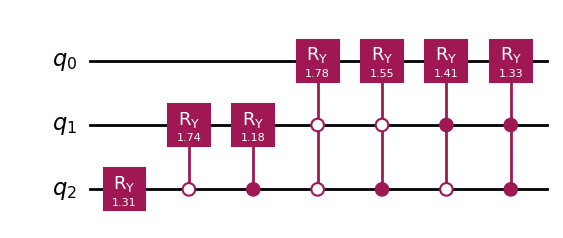

In [53]:
prob_distrib_qc.draw(output='mpl')

In [54]:
prob_distrib_qc = make_qc_for_dict(dict_all_theta)

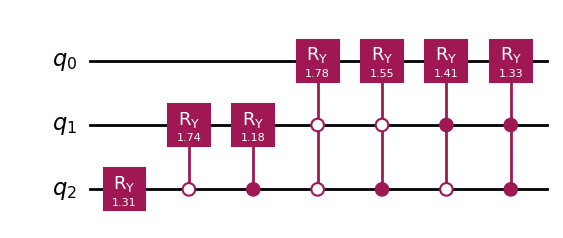

In [55]:
prob_distrib_qc.draw(output='mpl')

In [56]:
circ_prob_distrib = get_state_probabilities(prob_distrib_qc)

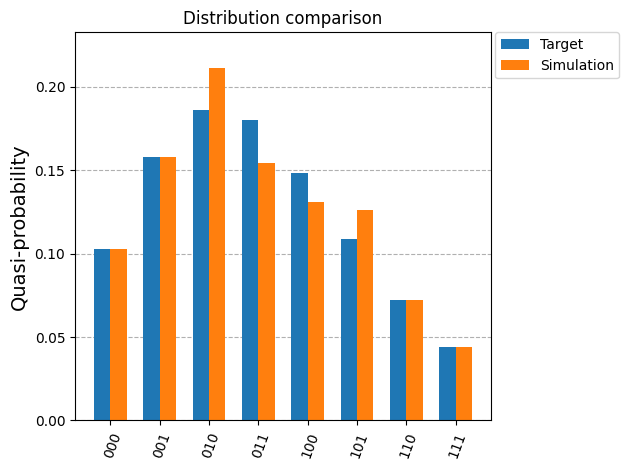

In [57]:
legend=["Target", "Simulation"]
plot_histogram([dict_pn, circ_prob_distrib], legend=legend, title="Distribution comparison", bar_labels=False)

Define a function `make_distribution_circuit`$(n, \mathrm{pricing\_dict}, m)$ that creates the circuit encoding the probability distribution.

In [58]:
def make_distribution_circuit(n, price_dict, m):
    # 1. Grid and probability distribution
    grid, prob_distribs = make_probability_distribution(n, price_dict, m)
    
    # 2. Dictionary q_w^[n]
    dict_at_n = make_dict_at_n(n, prob_distribs)
    
    # 3. All dictionaries q_w^[m]
    all_dicts_q = make_all_dictQ(n, dict_at_n)
    
    # 4. All theta angles
    all_thetas = make_all_dictTheta(all_dicts_q)
    
    # 5. Quantum circuit
    qc = make_qc_for_dict(all_thetas)
    
    return qc

## Full pricing circuit and amplitude estimation

We now combine all previous ingredients:
- the circuit preparing the discretized probability distribution,
- the comparator identifying the states above the strike,
- the affine rotations encoding the normalized payoff.

The final goal is to estimate, through Quantum Amplitude Estimation, a quantity related to the expected payoff of the call option.


# Full integration

In [59]:
circ_dict = {'n': 3, 'd': 0.01, 'num_stddev': 3, 'm': 3}
K = 2.0

## Creation of the affine functions $f_0$ and $f_1$

In [60]:
def get_first_function(cr_dict):
    d = cr_dict['d']
    return np.pi / 4 - d / 2, 0

def get_second_function(cr_dict, pr_dict, K):
    n = cr_dict['n']
    m = cr_dict['m']
    d = cr_dict['d']
    
    L, _  = align(n, K, pr_dict, m)          
    grille = make_final_price_grid(n, pr_dict, m)
    S_m   = grille[0]
    S_M   = grille[2**n - 1]                 
    
    coef  = d * (S_M - S_m) / ((S_M - K) * (2**n - 1))
    return -L * coef, coef
    

Compare the expectation we are computing with the expectation of its sine approximation

In [61]:
def compare_expect(circ_dict, price_dict, K):
    n = circ_dict['n']
    num_stddev = circ_dict['num_stddev']
    d = circ_dict['d']
    _, prdist = make_probability_distribution(n, price_dict, num_stddev)
    last_prices = make_final_price_grid(n, price_dict, num_stddev)
    L, sL = align(n, K, price_dict, num_stddev)
    sM = last_prices[-1]
    sum = 0
    mean_sin = 0
    a1, b1 = get_first_function(circ_dict)
    a2, b2 = get_second_function(circ_dict, price_dict, K)  
    for i in range(0, 2**n):
        fi = (last_prices[i] - sL)*(i>=L)/(sM - sL)
        f_0_1 = a1 + b1*i + (a2 + b2 * i) * (i>=L)
        sum += fi* prdist[i]
        mean_sin += np.sin(f_0_1)**2* prdist[i]
    mean_f = d*sum + (1-d)*0.5
    return mean_f, mean_sin

In [62]:
expect, sin_expect = compare_expect(circ_dict, price_dict, K)

In [63]:
expect, sin_expect

(np.float64(0.49689554820761006), np.float64(0.4968501944888616))

In [64]:
def make_first_function_circuit(cr_dict):
    n = cr_dict['n']
    a, b = get_first_function(cr_dict)
    res = encode_affine_function(n, a, b)
    return res

def make_second_function_circuit(cr_dict, pr_dict, K):
    n = cr_dict['n']
    a, b = get_second_function(cr_dict, pr_dict, K)
    res = encode_affine_function(n, a, b)
    return res

## Comparison circuit

In [65]:
def make_comparison_circuit(circ_dict, price_dict, K):
    n = circ_dict['n']
    m = circ_dict['m']
    L, _  = align(n, K, price_dict, m) 
    return make_comparator(n, L)

## Integration

In [66]:
def integration(circ_dict, price_dict, K):
    n = circ_dict['n']
    m = circ_dict['m']
    num_stddev = circ_dict['num_stddev']
    input = QuantumRegister(n, name="Input")
    funcOutput = QuantumRegister(1, name="FuncOutput")
    CMPancilla = QuantumRegister(n-1, name="AncillaCMP")
    CMPoutput = QuantumRegister(1, name="CMPOutput")
    prob_dist_qc = make_distribution_circuit(n, price_dict, num_stddev)
    prob_dist_gate = prob_dist_qc.to_gate(label='prob_dist')
    f0_qc = make_first_function_circuit(circ_dict)
    f0_gate = f0_qc.to_gate(label='f0')
    f1_qc = make_second_function_circuit(circ_dict, price_dict, K)
    f1_gate = f1_qc.to_gate(label='f1')
    ctl_f1_gate = f1_gate.control(1)
    cmp_qc = make_comparison_circuit(circ_dict, price_dict, K)
    cmp_gate = cmp_qc.to_gate(label='cmp')
    res = QuantumCircuit(CMPoutput, CMPancilla, funcOutput, input)
    res.append(prob_dist_gate, input)
    res.append(cmp_gate, CMPoutput[:] + CMPancilla[:] + input[:])
    res.append(f0_gate, funcOutput[:] + input[:])
    res.append(ctl_f1_gate, CMPoutput[:] + funcOutput[:] + input[:])
    return res



In [67]:
qc_pricer = integration(circ_dict, price_dict, K)

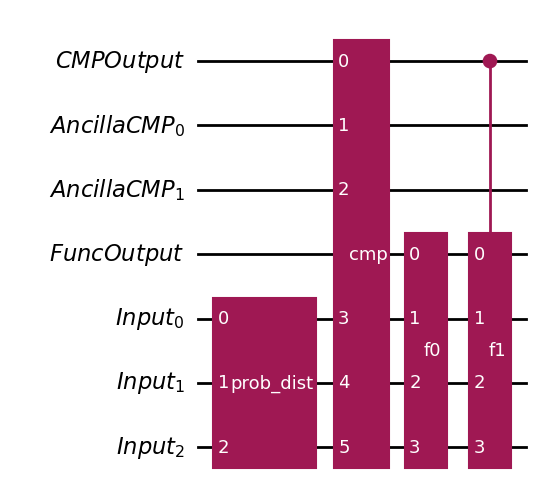

In [68]:
qc_pricer.draw('mpl')

In [69]:
def qae_eval(qc_pricer, num_shots):
    obj_qubits = qc_pricer.find_bit(qc_pricer.qregs[2][0])
    eps = 1.0/num_shots
    sampler = Sampler()
    problem = EstimationProblem(state_preparation=qc_pricer, objective_qubits=[obj_qubits.index]) 
    iae = FasterAmplitudeEstimation(
        maxiter=num_shots,  # Target accuracy
        delta=0.05,  # Confidence level
        sampler = sampler
    )
    result = iae.estimate(problem).estimation
    return result

In [70]:
res = qae_eval(qc_pricer, 7)

In [71]:
print(f'sin_expect: {sin_expect}, res: {res}')

sin_expect: 0.4968501944888616, res: 0.4959034130208258


## Discussion: advantages and limitations

The main advantage of the quantum approach is that it reformulates option pricing as an **amplitude estimation problem**.  
In theory, Quantum Amplitude Estimation is attractive because it can estimate expectations more efficiently than standard Monte Carlo methods.

However, our implementation also shows several practical limitations:

- the circuit is quite complex and requires many intermediate ingredients,
- the method relies on several approximations: price-grid discretization, strike projection on the grid, and the sine-based affine approximation,
- the final result also depends on the precision of the amplitude estimation routine,
- for the small problem sizes considered here, the method is mainly a proof of concept rather than a practical competitor to classical pricing.

## Conclusion

In this notebook, we built a quantum circuit that approximates the compounded price of a European call option.  
Starting from Black-Scholes and Monte Carlo benchmarks, we discretized the final stock price distribution, encoded it into a quantum state, and used controlled affine rotations together with a comparator to represent the payoff.  
We then applied amplitude estimation to extract a value related to the expected payoff.

Overall, the project illustrates well how a quantum finance algorithm is assembled from several building blocks.  
It also shows that the theoretical interest of the method is strong, even though the practical implementation remains approximate and technically demanding.
